In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 📌 Problem Statement

# OYO operates a large number of budget and mid-range hotels across major Indian cities, where room prices vary based on factors such as location, hotel type, amenities, and customer perception.
# The objective of this project is to perform exploratory data analysis on OYO hotel data to understand pricing patterns, identify key factors influencing final room prices, and analyze how ratings, amenities, and service levels relate to hotel pricing across different cities.

# 📊 Dataset Description (Column-wise)
# 1️⃣ Final_Price

# The final room price (in INR) paid by a customer per night, excluding additional taxes.
# This is the primary target variable used to analyze pricing patterns.

# 2️⃣ Original_Price

# The original listed price of the hotel before any discounts are applied.
# Used to understand discount strategies and price reductions.

# 3️⃣ Discount

# The discount percentage offered on the original price.
# Helps evaluate promotional intensity across hotels and cities.

# 4️⃣ Tax_Amount

# Additional taxes and fees charged per room per night (in INR).
# Used to compute the effective cost paid by customers.

# 5️⃣ Effective_Price

# The total cost paid by a customer per night, calculated as:
# Final_Price + Tax_Amount.
# This represents the true booking cost.

# 6️⃣ Rating

# The average customer rating of the hotel on a scale of 1 to 5.
# Used to assess hotel quality and customer satisfaction.

# 7️⃣ Number of Ratings

# The total number of customer reviews received by the hotel.
# Acts as a measure of trust and popularity.

# 8️⃣ Rating_Category

# A categorical representation of hotel ratings such as Excellent, Very Good, Good, Fair, and NEW.
# Provides an easy-to-understand quality classification.

# 9️⃣ Popularity_Score

# A derived metric calculated as:
# Rating × Number of Ratings.
# Used to combine quality and popularity into a single measure.

# 🔟 Amenity_Count

# The total number of amenities offered by the hotel.
# Used to evaluate service richness and its impact on pricing.

# 1️⃣1️⃣ Hotel_Type

# The category of hotel such as Townhouse, Hotel O, Flagship, etc.
# Helps compare pricing and quality across different hotel formats.

# 1️⃣2️⃣ Company_Serviced

# Indicates whether the hotel is managed directly by OYO (Yes/No).
# Used to analyze service consistency and price differences.

# 1️⃣3️⃣ Wizard_Member

# Indicates whether the hotel participates in OYO’s Wizard loyalty program (Yes/No).
# Used to assess the impact of membership benefits on pricing.

# 1️⃣4️⃣ City

# The city where the hotel is located.
# Used for geographic comparison of prices, ratings, and availability.

# 1️⃣5️⃣ Price_Category

# Hotels are grouped into Budget, Mid, Premium, and Luxury based on Final_Price.
# Helps in segmentation and comparative analysis.

In [2]:
df=pd.read_csv(r'cleanedData_oyo_rooms.csv')
df.drop(columns=['Unnamed: 0','Amenities'],inplace=True)

In [3]:
new_order = [
    'Clean_Hotel_Name',
    'Hotel_Type',
    'City',
    'Wizard_Member',
    'Company_Serviced',
    'Original_Price',
    'Discount',
    'Discount_Amount',
    'Final_Price',
    'Tax_Amount',
    'Effective_Price',
    'Price_Category',
    'Rating',
    'Rating_Category',
    'Number of Ratings',
    'Popularity_Score',
    'Amenity_Count'
]
df = df[new_order]


In [4]:
df.head()

,Clean_Hotel_Name,Hotel_Type,City,Wizard_Member,Company_Serviced,Original_Price,Discount,Discount_Amount,Final_Price,Tax_Amount,Effective_Price,Price_Category,Rating,Rating_Category,Number of Ratings,Popularity_Score,Amenity_Count
0,Narayanaguda Metro Station,Townhouse,Hyderabad,Yes,Yes,7095,71,5365,1730,257,1987,Mid,4.3,Very Good,774,3328.2,20
1,Kothapet,Townhouse,Hyderabad,Yes,Yes,7695,79,6332,1363,239,1602,Mid,4.5,Excellent,320,1440.0,15
2,Madhapur Nera Regency,Townhouse,Hyderabad,Yes,Yes,6498,72,4893,1605,169,1774,Mid,4.3,Very Good,1793,7709.9,34
3,Saraswathi Residency Near SR Nagar Metro Station,Hotel O,Hyderabad,No,No,5381,71,4049,1332,175,1507,Mid,4.3,Very Good,6,25.8,12
4,Hotel Belsons Taj Mahal,Super Townhouse,Hyderabad,No,No,7942,72,5979,1963,261,2224,Mid,4.6,Excellent,82,377.2,49


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1791 entries, 0 to 1790
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Clean_Hotel_Name   1791 non-null   object 
 1   Hotel_Type         1791 non-null   object 
 2   City               1791 non-null   object 
 3   Wizard_Member      1791 non-null   object 
 4   Company_Serviced   1791 non-null   object 
 5   Original_Price     1791 non-null   int64  
 6   Discount           1791 non-null   int64  
 7   Discount_Amount    1791 non-null   int64  
 8   Final_Price        1791 non-null   int64  
 9   Tax_Amount         1791 non-null   int64  
 10  Effective_Price    1791 non-null   int64  
 11  Price_Category     1791 non-null   object 
 12  Rating             1791 non-null   float64
 13  Rating_Category    1791 non-null   object 
 14  Number of Ratings  1791 non-null   int64  
 15  Popularity_Score   1791 non-null   float64
 16  Amenity_Count      1791 

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(1583, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1583 entries, 0 to 1790
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Clean_Hotel_Name   1583 non-null   object 
 1   Hotel_Type         1583 non-null   object 
 2   City               1583 non-null   object 
 3   Wizard_Member      1583 non-null   object 
 4   Company_Serviced   1583 non-null   object 
 5   Original_Price     1583 non-null   int64  
 6   Discount           1583 non-null   int64  
 7   Discount_Amount    1583 non-null   int64  
 8   Final_Price        1583 non-null   int64  
 9   Tax_Amount         1583 non-null   int64  
 10  Effective_Price    1583 non-null   int64  
 11  Price_Category     1583 non-null   object 
 12  Rating             1583 non-null   float64
 13  Rating_Category    1583 non-null   object 
 14  Number of Ratings  1583 non-null   int64  
 15  Popularity_Score   1583 non-null   float64
 16  Amenity_Count      1583 non-n

# Univarite analysis

In [8]:
df['Final_Price'].min()

417

In [15]:
df['Final_Price'].max()

4883

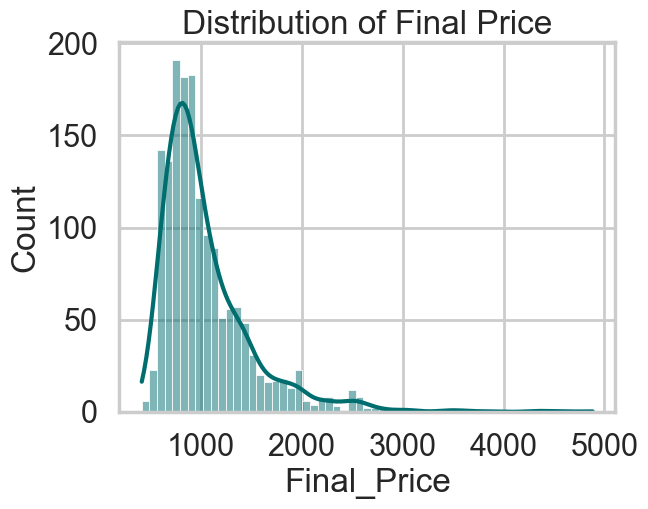

In [101]:
sns.histplot(data=df,x='Final_Price',kde=True,color='#006d6f')
plt.title('Distribution of Final Price')
sns.set_context('poster')
plt.plot
plt.savefig(r'C:\Users\masir\Downloads\Web_ScrapingProject\u1.jpg')

In [17]:
# The final price of OYO hotels ranges from ₹417 to ₹4,883, highlighting a wide pricing spectrum across properties.
# A strong concentration of hotels lies between ₹500 and ₹1,500, indicating OYO’s primary focus on the budget and mid-range accommodation segment.
# The price distribution is right-skewed, with a small number of premium hotels extending the upper price range.

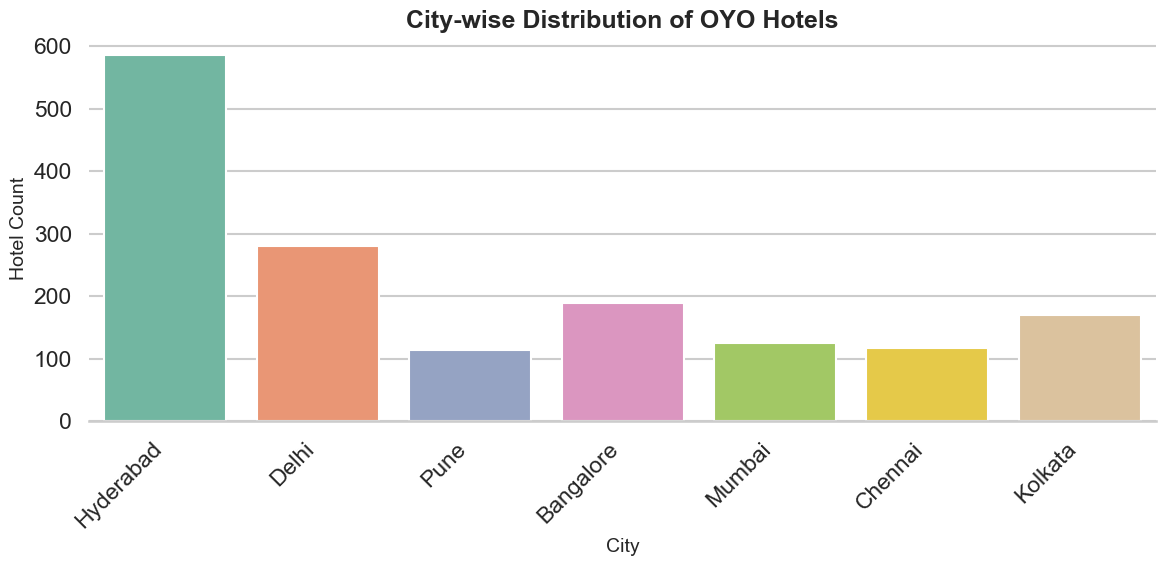

In [104]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='City',
    palette='Set2'
)

plt.title(
    'City-wise Distribution of OYO Hotels',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('City', fontsize=14)
plt.ylabel('Hotel Count', fontsize=14)

plt.xticks(rotation=45, ha='right')

sns.despine(left=True)
plt.tight_layout()

# ✅ SAVE FIRST
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\u2.png',
    dpi=300,
    bbox_inches='tight'
)

# ✅ THEN SHOW
plt.show()


In [19]:
# Hyderabad has the highest number of OYO hotels, mainly because many people live and work there due to IT and other industries.

# Delhi and Bangalore also have a high number of hotels, as they are major cities with business and travel demand.

# Kolkata has a moderate number of OYO hotels, while Mumbai, Chennai, and Pune have fewer hotels compared to the top cities.

# Overall, OYO hotels are more concentrated in big cities where population and travel demand are high.

In [20]:
df['Rating'].min()


2.0

In [21]:
df['Rating'].max()

5.0

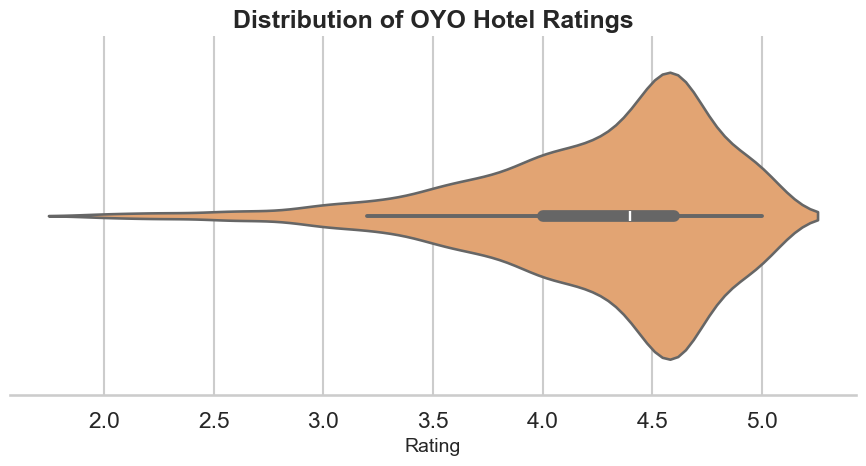

In [10]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(9,5))

sns.violinplot(
    data=df,
    x='Rating',
    color='#F4A261'
)

plt.title(
    'Distribution of OYO Hotel Ratings',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Rating', fontsize=14)

sns.despine(left=True)
plt.tight_layout()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\u3.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()






In [23]:
# 50% of the ratings lie between 4.0 and 4.65, showing that most customers are highly satisfied with their stay.
# Ratings are concentrated around 4.6, indicating consistently positive customer experiences across hotels.
# Very few low ratings (below 3) suggest limited customer dissatisfaction and fewer service issues.
# High satisfaction is likely driven by affordable pricing, good amenities, and convenient locations, making OYO a preferred choice for many travelers.

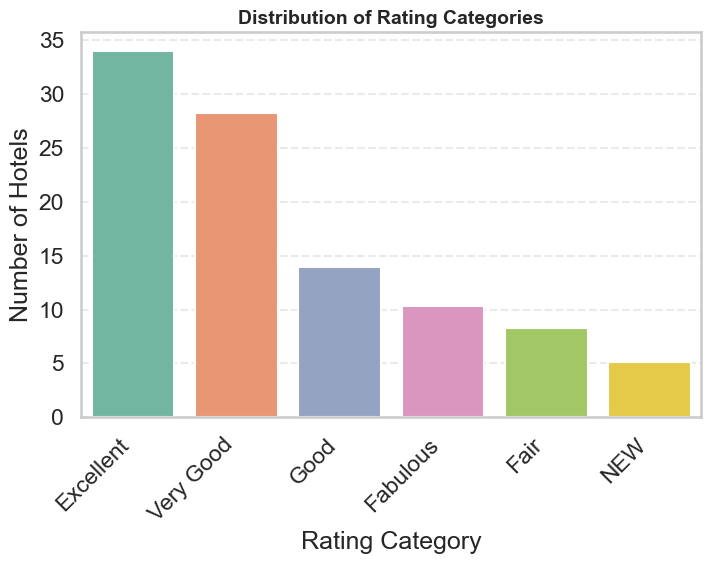

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Rating_Category',
    palette='Set2',
    order=df['Rating_Category'].value_counts().index,
    stat='percent'
)
plt.xticks(rotation=45,ha='right')
plt.title('Distribution of Rating Categories', fontsize=14, weight='bold')
plt.xlabel('Rating Category')
plt.ylabel('Number of Hotels')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\u4.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [25]:
# Most OYO hotels fall under “Excellent” and “Very Good” categories, indicating strong overall customer satisfaction.
# “Good” rated hotels form a moderate share, suggesting acceptable service quality with scope for improvement.
# Very few hotels are rated as “Fair” or “NEW”, showing limited negative feedback and fewer newly listed properties.
# Overall, the rating distribution is positively skewed, highlighting consistent service quality across most OYO hotels.

In [26]:
df.head()

,Clean_Hotel_Name,Hotel_Type,City,Wizard_Member,Company_Serviced,Original_Price,Discount,Discount_Amount,Final_Price,Tax_Amount,Effective_Price,Price_Category,Rating,Rating_Category,Number of Ratings,Popularity_Score,Amenity_Count
0,Narayanaguda Metro Station,Townhouse,Hyderabad,Yes,Yes,7095,71,5365,1730,257,1987,Mid,4.3,Very Good,774,3328.2,20
1,Kothapet,Townhouse,Hyderabad,Yes,Yes,7695,79,6332,1363,239,1602,Mid,4.5,Excellent,320,1440.0,15
2,Madhapur Nera Regency,Townhouse,Hyderabad,Yes,Yes,6498,72,4893,1605,169,1774,Mid,4.3,Very Good,1793,7709.9,34
3,Saraswathi Residency Near SR Nagar Metro Station,Hotel O,Hyderabad,No,No,5381,71,4049,1332,175,1507,Mid,4.3,Very Good,6,25.8,12
4,Hotel Belsons Taj Mahal,Super Townhouse,Hyderabad,No,No,7942,72,5979,1963,261,2224,Mid,4.6,Excellent,82,377.2,49


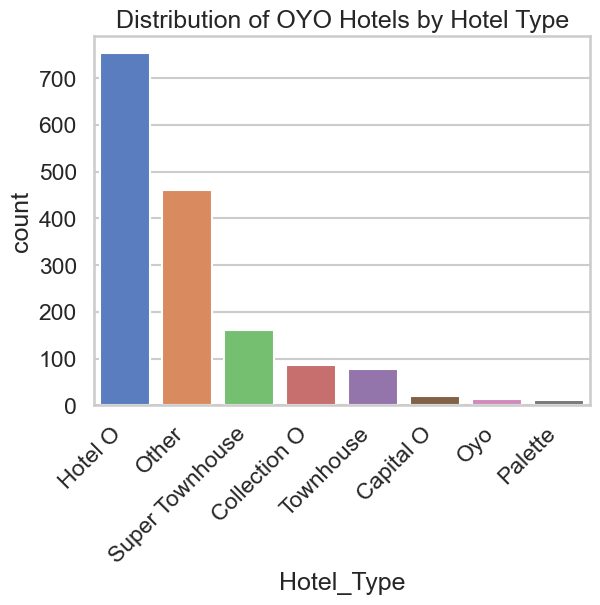

In [12]:
sns.countplot(data=df,x='Hotel_Type',palette='muted',order=df['Hotel_Type'].value_counts().index)
plt.title('Distribution of OYO Hotels by Hotel Type')
plt.xticks(rotation=45,ha='right')
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\u5.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [28]:
# “Hotel O” is the most dominant category, showing that OYO primarily focuses on standard budget hotel offerings.
# “Other” and “Super Townhouse” categories also have a strong presence, indicating diversification into premium and alternative stays.
# Townhouse and Collection O hotels form a moderate share, catering to customers looking for better amenities and comfort.
# Capital O, Palette, and OYO-branded hotels are limited, suggesting niche or premium segments with selective availability.

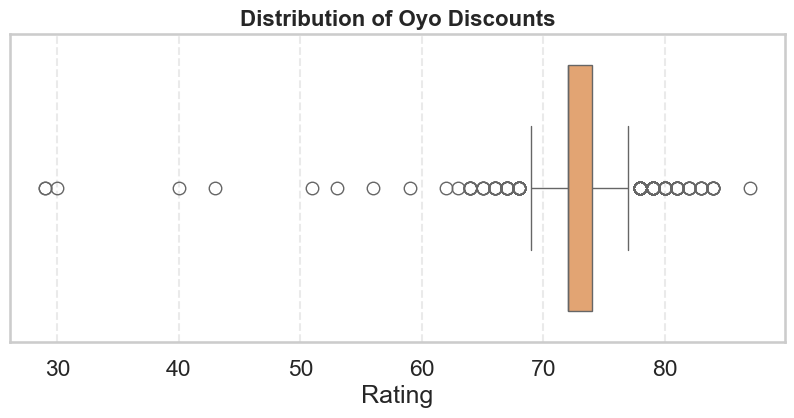

In [94]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    x=df['Discount'],
    color='#F4A261'   # solid, presentation-friendly color
)

plt.title('Distribution of Oyo Discounts', fontsize=16, weight='bold')
plt.xlabel('Rating')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

In [30]:
# Most OYO hotels offer high discounts between 67% and 78%, indicating strong price-based attraction strategies.
# Only a small number of hotels provide very low discounts, likely due to premium positioning or higher maintenance costs.
# Very few hotels offer discounts above 80%, suggesting such heavy discounts are used selectively.
# Overall, OYO focuses on affordable pricing for the majority of customers, balancing competitiveness and profitability.

[]

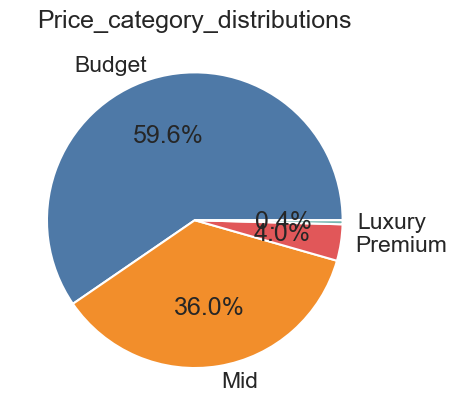

In [14]:
plt.pie(df['Price_Category'].value_counts(),labels=df['Price_Category'].value_counts().index,autopct='%1.1f%%',colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']
)
plt.title('Price_category_distributions')
plt.axis()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\u6.png',
    dpi=300,
    bbox_inches='tight')
plt.plot() 

In [32]:
# Most OYO hotels are budget hotels, so they are affordable for common travelers.
# Many hotels are in the mid-price range, giving customers better comfort at reasonable prices.
# Very few hotels are premium or luxury, showing OYO is not focused on costly stays.
# Overall, OYO mainly targets people looking for affordable and value-for-money hotels.

[]

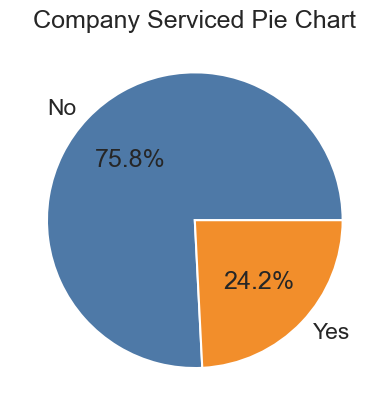

In [96]:
plt.pie(df['Company_Serviced'].value_counts(),labels=df['Company_Serviced'].value_counts().index,autopct='%1.1f%%',colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']
)
plt.title('Company Serviced Pie Chart')
plt.axis()
plt.plot() 

In [35]:
# Around 76% of OYO hotels are not company-serviced, meaning most properties are managed independently by hotel owners.

# Only about 26% of hotels are company-serviced, showing OYO operates a limited number of hotels directly.

# This indicates OYO mainly follows an asset-light business model, focusing on partnerships rather than owning hotels.

# The model helps OYO expand quickly across cities while reducing operational and maintenance costs.

# Bivariate Analysys

In [32]:
df['City'].replace('Bengaluru','Bangalore',inplace=True)

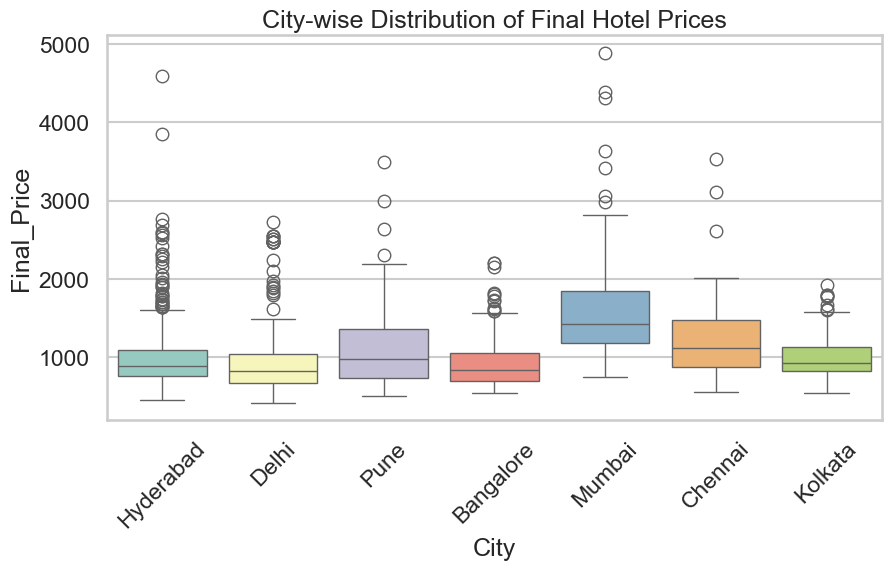

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='City', y='Final_Price', palette='Set3')
plt.xticks(rotation=45)
plt.title('City-wise Distribution of Final Hotel Prices')
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\b1.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [63]:
# Mumbai has the highest median hotel price, indicating that staying in Mumbai is generally more expensive compared to other cities.

# Hyderabad and Delhi have lower and more consistent prices, showing they offer more affordable and stable pricing options for customers.

# Price variation is highest in Mumbai and Pune, suggesting the presence of both budget and premium hotels in these cities

# Most cities have several high-price outliers, which indicates a small number of premium or luxury hotels charging significantly higher prices.
# Bangalore, Chennai, and Kolkata show mid-range pricing, making them balanced markets with reasonable affordability and moderate price spread.

In [18]:
cross_tab=pd.crosstab(df['Price_Category'],df['Rating_Category'],margins=True)

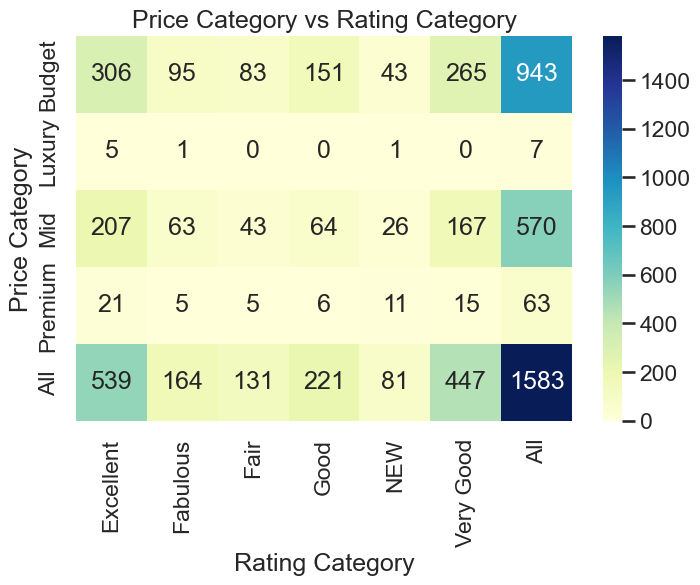

In [19]:

plt.figure(figsize=(8,5))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Price Category vs Rating Category')
plt.xlabel('Rating Category')
plt.ylabel('Price Category')
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\b2.png',
    dpi=300,
    bbox_inches='tight')
plt.show()

In [20]:
# Budget hotels get many high ratings, showing that low price hotels can still make customers happy.
# Expensive hotels are not always better, as higher price does not always mean higher ratings.
# Mid-range hotels perform well, offering good quality at a reasonable price.
# Low ratings are seen in all price ranges, so paying more does not guarantee better service.
# Customers care more about good service and amenities than price, and they reward hotels that give value for money.

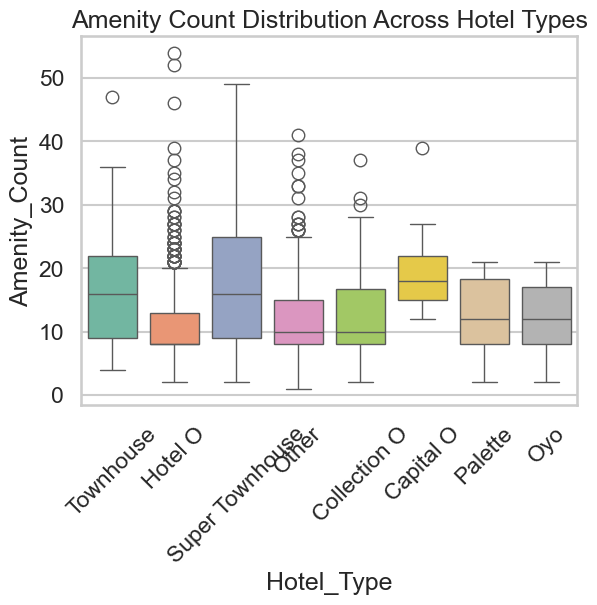

In [22]:
sns.boxplot(data=df, x='Hotel_Type', y='Amenity_Count', palette='Set2')
plt.xticks(rotation=45)
plt.title('Amenity Count Distribution Across Hotel Types')
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\b4.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [68]:
# Super Townhouse, Townhouse, and Capital O hotels offer the highest number of amenities, making them more comfortable for customers.

# More amenities generally mean better comfort and stay experience, which customers value more than just the hotel name.

# OYO and Palette hotels also provide a reasonable number of amenities, making them good affordable options.

# Some Hotel O and Collection O properties offer very high amenities, showing that amenities can vary a lot within the same hotel type

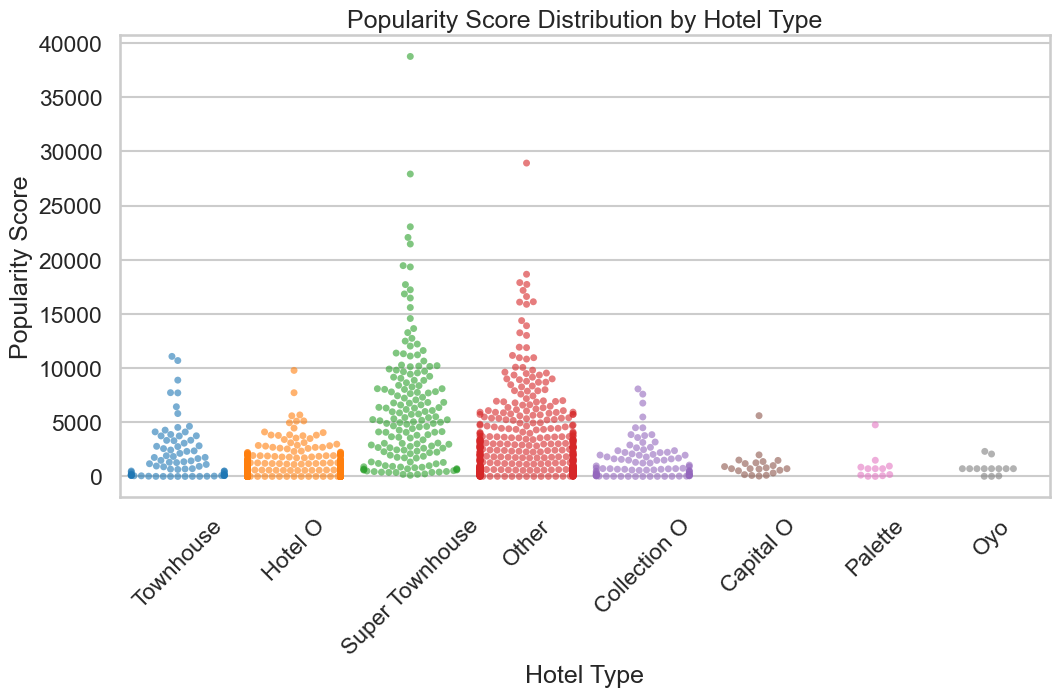

In [69]:
plt.figure(figsize=(12,6))
sns.swarmplot(
    data=df,
    x='Hotel_Type',
    y='Popularity_Score',
    alpha=0.6,
    hue='Hotel_Type'
)
plt.xticks(rotation=45)
plt.title('Popularity Score Distribution by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Popularity Score')
plt.show()

In [70]:
# Super Townhouse hotels are the most popular, with the highest spread and peak popularity scores, showing strong customer trust due to good ratings and many reviews.

# “Other” hotel types also show high popularity, meaning customers frequently book and review these hotels positively.

# Townhouse, Hotel O, and Collection O have moderate popularity, suggesting decent service but fewer reviews or slightly lower engagement.

# Capital O, Palette, and OYO hotels have lower popularity scores, indicating fewer customer reviews or limited customer trust compared to other formats.

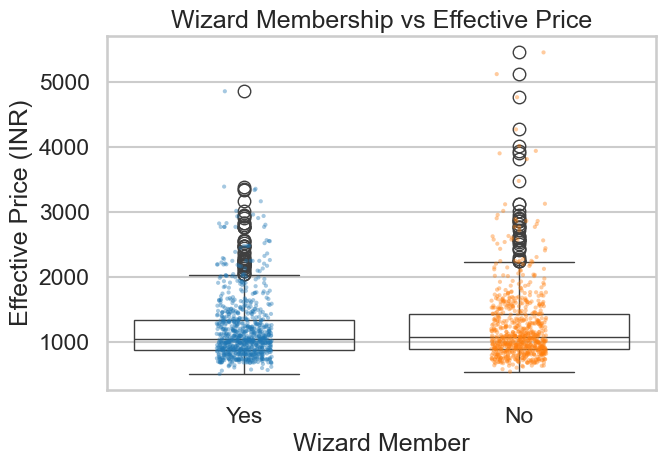

In [21]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Wizard_Member',
    y='Effective_Price',
    boxprops={'facecolor':'None'}
)

sns.stripplot(
    data=df,
    x='Wizard_Member',
    y='Effective_Price',
    jitter=True,
    alpha=0.4,
    size=3,
    hue='Wizard_Member'
)

plt.title('Wizard Membership vs Effective Price')
plt.xlabel('Wizard Member')
plt.ylabel('Effective Price (INR)')
plt.tight_layout()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\b3.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [72]:
# Hotels with Wizard membership generally offer slightly lower prices
# Both Wizard and non-Wizard hotels are available across similar price ranges
# Higher-priced hotels are more commonly seen without Wizard membership
# Wizard hotels are more concentrated in affordable price options

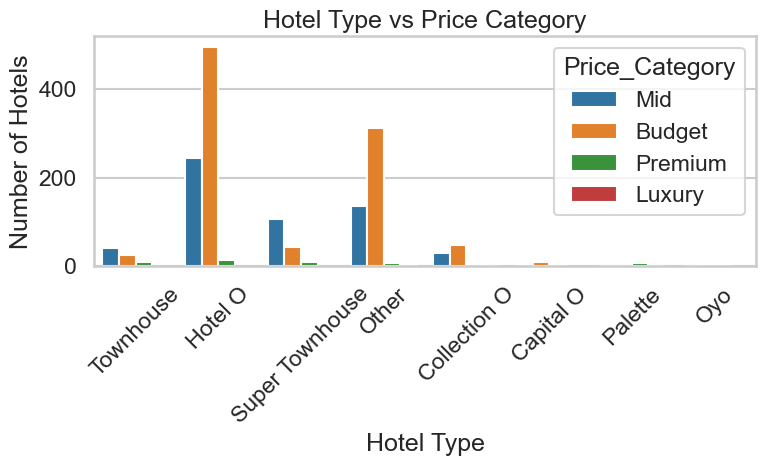

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Hotel_Type', hue='Price_Category')
plt.title('Hotel Type vs Price Category')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Hotels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\b5.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [74]:
# Hotel O and Collection O hotels are mostly in the budget category, offering good service at reasonable prices
# Hotel O, Super Townhouse, and Other hotel types have a strong presence in the mid-price category, suitable for customers looking for better comfort at affordable rates
# Super Townhouse, Palette, and OYO also appear in the premium category, but prices vary within these hotel types
# Overall, customers can choose different hotel types based on budget, comfort needs, and price range

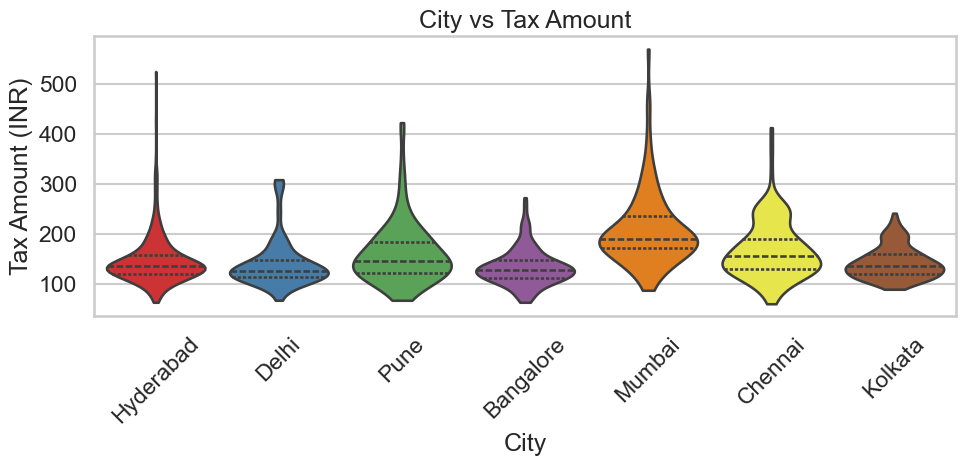

In [75]:

plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x='City',
    y='Tax_Amount',
    inner='quartile',
    cut=0,palette='Set1'
)

plt.title('City vs Tax Amount')
plt.xlabel('City')
plt.ylabel('Tax Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [76]:
# Mumbai and Pune have higher taxes, mainly because hotels in these cities are usually priced higher
# Bangalore and Delhi have lower taxes, as more hotels fall in budget and mid-price ranges
# Cities like Mumbai and Chennai show more variation in taxes, meaning both budget and premium hotels are available
# Higher room prices usually lead to higher taxes, increasing the total booking cost

In [77]:
df.groupby(['City'])['Discount'].mean() 

City
Bangalore    73.136842
Chennai      72.813559
Delhi        72.478571
Hyderabad    73.133106
Kolkata      73.911765
Mumbai       71.880000
Pune         72.754386
Name: Discount, dtype: float64

In [25]:
city_weighted_rating = (
    df.groupby('City')
      .apply(lambda x: (x['Rating'] * x['Number of Ratings']).sum() / x['Number of Ratings'].sum())
      .sort_values(ascending=False)
)

city_weighted_rating.head(5)


City
Delhi        4.574293
Bangalore    4.565576
Kolkata      4.543781
Hyderabad    4.515130
Chennai      4.433655
dtype: float64

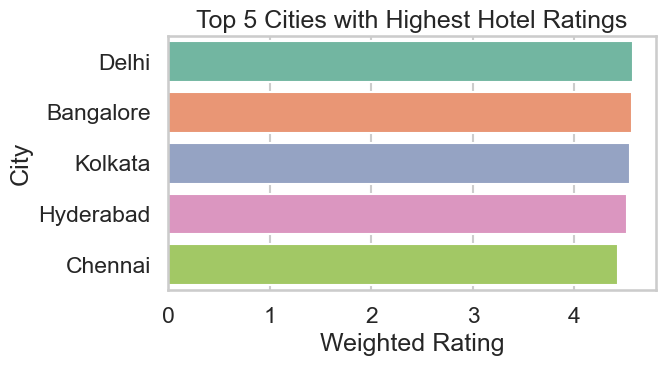

In [26]:
top5 = city_weighted_rating.head(5)

plt.figure(figsize=(7,4))
sns.barplot(
    x=top5.values,
    y=top5.index,
    hue=top5.index,
    palette='Set2'
)

plt.title('Top 5 Cities with Highest Hotel Ratings')
plt.xlabel('Weighted Rating')
plt.ylabel('City')
plt.tight_layout()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\b6.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


# Multivariate analysis

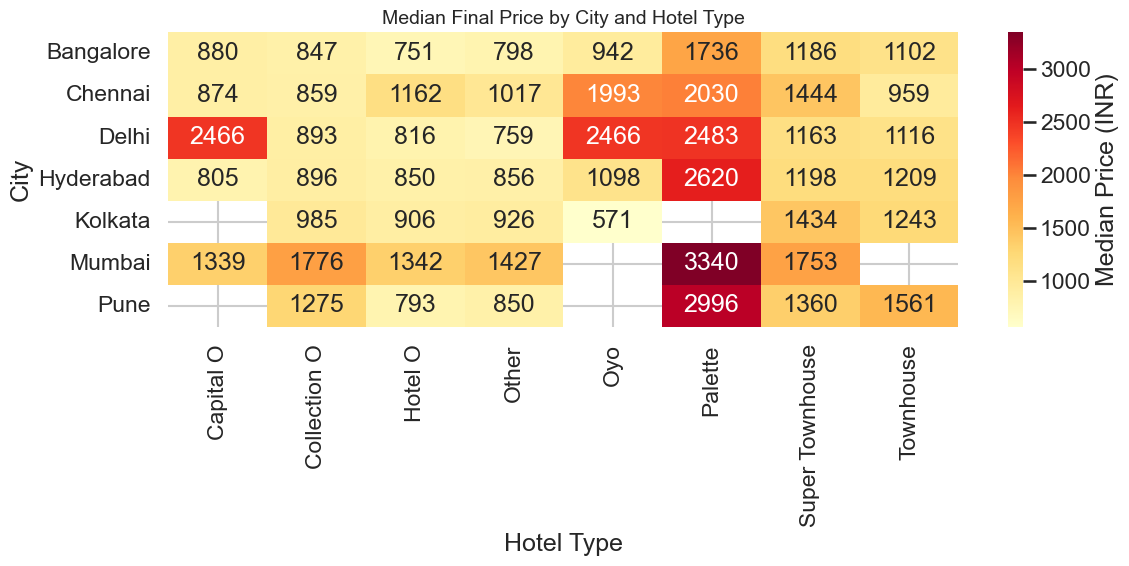

In [35]:
pivot = (
    df.groupby(['City', 'Hotel_Type'])['Final_Price']
      .median()
      .unstack()
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',        # clean professional palette
    mask=pivot.isna(),   # ⬅️ hides missing cells
    linewidths=0,        # ⬅️ removes grid lines
    cbar_kws={'label': 'Median Price (INR)'}
)

plt.title('Median Final Price by City and Hotel Type', fontsize=14)
plt.xlabel('Hotel Type')
plt.ylabel('City')
plt.tight_layout()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\m1.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [84]:
# Hotel O and Collection O have the lowest median prices across most cities, making them budget-friendly options

# Townhouse and Super Townhouse mostly fall in the mid-price range, offering better comfort at reasonable prices

# Palette hotels show the highest median prices, especially in Mumbai, Delhi, and Pune, indicating premium positioning

# Mumbai and Delhi generally show higher median prices across multiple hotel types, while Bangalore and Hyderabad remain relatively more affordable

# Hotel prices vary significantly by both city and hotel type, allowing customers to choose budget, mid-range, or premium stays based on their location and comfort needs

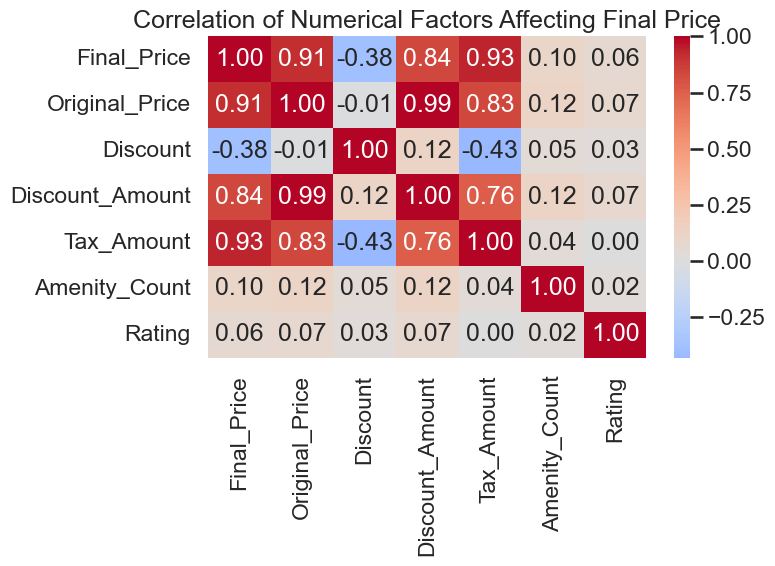

In [36]:
price_related_cols = [
    'Final_Price',
    'Original_Price',
    'Discount',
    'Discount_Amount',
    'Tax_Amount',
    'Amenity_Count',
    'Rating'
]

corr_filtered = df[price_related_cols].corr()
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_filtered,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation of Numerical Factors Affecting Final Price')
plt.tight_layout()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\m2.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [86]:
# Final price is mainly driven by the original price — higher listed prices directly lead to higher final prices

# Taxes increase along with room prices, which means expensive hotels add a bigger tax burden to customers

# Discounts help reduce the final price, showing that promotions play a real role in making hotels more affordable

# Amenities have only a small impact on pricing, suggesting hotels don’t increase prices heavily just for adding amenities

# Hotel ratings have very little influence on price, meaning highly rated hotels are not always expensive

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1583 entries, 0 to 1790
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Clean_Hotel_Name   1583 non-null   object 
 1   Hotel_Type         1583 non-null   object 
 2   City               1583 non-null   object 
 3   Wizard_Member      1583 non-null   object 
 4   Company_Serviced   1583 non-null   object 
 5   Original_Price     1583 non-null   int64  
 6   Discount           1583 non-null   int64  
 7   Discount_Amount    1583 non-null   int64  
 8   Final_Price        1583 non-null   int64  
 9   Tax_Amount         1583 non-null   int64  
 10  Effective_Price    1583 non-null   int64  
 11  Price_Category     1583 non-null   object 
 12  Rating             1583 non-null   float64
 13  Rating_Category    1583 non-null   object 
 14  Number of Ratings  1583 non-null   int64  
 15  Popularity_Score   1583 non-null   float64
 16  Amenity_Count      1583 non-n

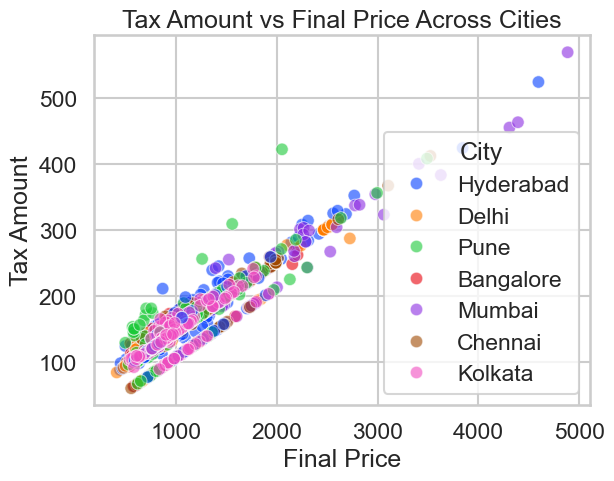

In [37]:
sns.scatterplot(
    data=df,
    x='Final_Price',
    y='Tax_Amount',
    hue='City',
    alpha=0.6,
    palette='bright'
)
plt.title('Tax Amount vs Final Price Across Cities')
plt.xlabel('Final Price')
plt.ylabel('Tax Amount')
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\m3.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [90]:
# Tax amount increases steadily with final price across all cities, showing a consistent pricing–tax structure

# Mumbai and Hyderabad show the highest tax values at higher price levels, indicating a higher overall cost burden for expensive hotels

# Bangalore and Kolkata are more concentrated in lower price and tax ranges, making them relatively more affordable for budget travelers

# Delhi and Chennai fall in the mid-to-high range, with taxes rising sharply as hotel prices increase

# At similar final prices, tax amounts remain fairly consistent across cities, suggesting tax is largely price-driven rather than city-specific

In [39]:
df['Amenity_Level'] = pd.cut(
    df['Amenity_Count'],
    bins=[0, 10, 20, 60],
    labels=[
        'Low Amenities (0–10)',
        'Medium Amenities (11–20)',
        'High Amenities (21+)'
    ]
)


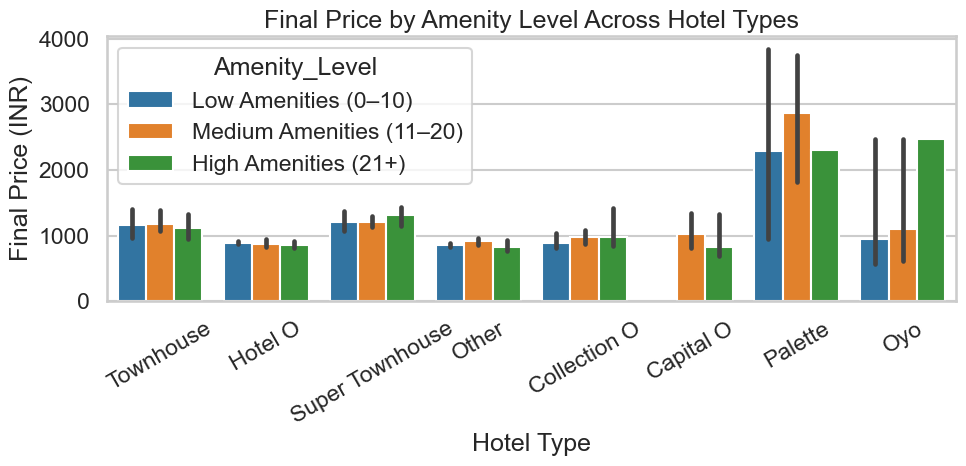

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Hotel_Type',
    y='Final_Price',
    hue='Amenity_Level',
    estimator=np.median   # safer than mean
)

plt.xticks(rotation=30)
plt.title('Final Price by Amenity Level Across Hotel Types')
plt.xlabel('Hotel Type')
plt.ylabel('Final Price (INR)')
plt.tight_layout()
plt.savefig(
    r'C:\Users\masir\Downloads\Web_ScrapingProject\m4.png',
    dpi=300,
    bbox_inches='tight')
plt.show()


In [93]:
# Hotels with more amenities usually charge higher prices across most hotel types

# In budget hotel types, prices increase only slightly even when amenities increase

# Mid-range hotel types show a clear price increase as amenities move from low to high

# Premium hotel types already start at higher prices, so additional amenities change prices less

# Overall, amenities influence price, but hotel type matters more
